# Importar Librerias


- **NLTK (español):** Se usa nltk, ya que esta libreria ofrece interfaces fáciles de usar para más de 50 corpus y recursos léxicos como WordNet, además de un conjunto de bibliotecas de procesamiento de texto para clasificación, tokenización, lematización, etiquetado, análisis sintáctico y razonamiento semántico, contenedores para bibliotecas de PLN de alto rendimiento y un foro de discusión activo. En este caso se usa para integrar stopwords en español en el TfidfVectorizer.

- **scikit-learn:** Ofrece un ecosistema unificado para el flujo completo: `TfidfVectorizer` para BOW con peso TF-IDF, `Pipeline` para encadenar transformaciones de forma reproducible, `TruncatedSVD` y `Normalizer` para reducción de dimensionalidad y escalado, y modelos (Ejemplo. Logistic Regression, SVC, Random Forest) con `GridSearchCV` para búsqueda de hiperparámetros y métricas estándar (F1, accuracy).

In [9]:
import nltk
from nltk.corpus import stopwords
import pandas as pd 
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

nltk.download('stopwords')
spanish_stopwords = stopwords.words('spanish')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laristizabal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Punto 1
Preparación de los textos utilizando el esquema de bolsa de palabras (BOW)l con una pesado TF-IDF. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.

## Exploración de datos 

En esta sección se carga el dataset (`Train_textosODS.xlsx`), se revisan dimensiones, nombres de columnas (`shape`, `columns`) y la estructura de los datos con `info()` (tipos, nulos). Con `head()` se inspeccionan las primeras filas para comprobar el formato de los textos y la variable objetivo ODS.

### Hallazgos del analisis exploratorio
El conjunto de datos está compuesto por textos asociados a 16 Objetivos de Desarrollo Sostenible (ODS), al analizar la distribución de los textos por clase se observa que los ODS 16, 5 y 4 concentran la mayor cantidad de textos, mientras que los ODS 12, 15 y 9 presentan la menor cantidad de textos, No obstante, el desbalance entre clases es moderado y no representa una diferencia extrema entre el ODS con mayor y menor número de textos, adicional el dataset no contiene textos vacíos ni registros duplicados.

Se observaron las siguientes características:

- Promedio de palabras en el texto son 111 palabras
- El minimo de palabras en un texto fue de 24 palabras
- El maximo de palabras en un texto fue de 268 palabras

Finalmente al analizar el corpus se identificó un vocabulario aproximado de 35000 términos únicos, lo que refleja la alta dimensionalidad de característica de los problemas de procesamiento de lenguaje natural.

In [10]:
# Lectura del data set 
data = pd.read_excel("../data/Train_textosODS.xlsx")

In [11]:
# Primeras 10 filas
data.head(10)

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5
5,Para los niños más pequeños (bebés y niños peq...,4
6,"Además, las consecuencias dañinas para el desa...",2
7,"Además, la formación de especialistas en medic...",3
8,"En Hai Phong, el monitoreo de la calidad del a...",11
9,Este capítulo se enfoca en las formas en que l...,16


In [12]:
# Shape df
print("Shape del dataframe:", data.shape)
# Columnas df
print("Columnas de df:", data.columns)

Shape del dataframe: (9656, 2)
Columnas de df: Index(['textos', 'ODS'], dtype='object')


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9656 entries, 0 to 9655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   textos  9656 non-null   object
 1   ODS     9656 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 151.0+ KB


In [14]:
# Longitud en caracteres de cada texto (número de caracteres por fila)
data['char_len'] = data['textos'].str.len()
# Longitud en palabras: split por espacios y cuenta de tokens por texto
data['word_len'] = data['textos'].str.split().str.len()

In [15]:
data[['char_len','word_len']].describe()

,char_len,word_len
count,9656.000000,9656.000000
mean,708.952465,111.017295
std,238.864636,37.082212
min,143.000000,24.000000
25%,522.000000,82.000000
50%,669.000000,105.000000
75%,864.000000,135.000000
max,1977.000000,268.000000


In [16]:
# Textos vacios 
print("Textos vacios :", (data['word_len'] < 5).mean())
#Duplicados 
print('Duplicados:', data['textos'].duplicated().sum())

Textos vacios : 0.0
Duplicados: 0


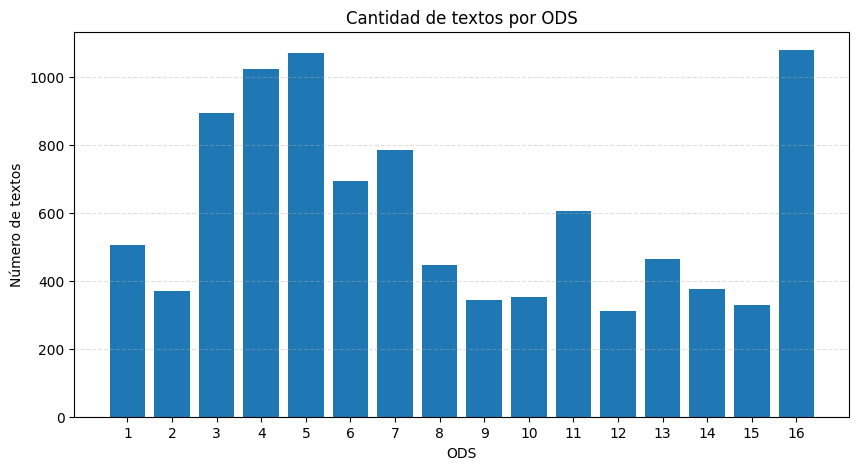

In [17]:
# Cantidad de Textos por ODS 
conteo = data["ODS"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(conteo.index, conteo.values)

plt.title("Cantidad de textos por ODS")
plt.xlabel("ODS")
plt.ylabel("Número de textos")

plt.xticks(conteo.index)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [18]:
# Tamaño del vocabulario 
cv = CountVectorizer(stop_words=None)
X_counts = cv.fit_transform(data['textos'])
len(cv.vocabulary_)

34799

In [19]:
# Top 10 de Stopwords 
sum_words = X_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) 
              for word, idx in cv.vocabulary_.items()]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
words_freq[:10]

[('de', np.int64(92263)),
 ('la', np.int64(52206)),
 ('en', np.int64(34949)),
 ('los', np.int64(30892)),
 ('el', np.int64(30157)),
 ('las', np.int64(21308)),
 ('que', np.int64(19548)),
 ('para', np.int64(14074)),
 ('del', np.int64(12897)),
 ('se', np.int64(11466))]

## Preparación de los datos

Para la división de los datos, se usa la función train_test_split, se agrega el parámetro stratify para conservar la misma proporción de clases que tiene el dataset original, esto es importante debido a que el conjunto de datos presenta cierto desbalance entre los diferentes ODS, adicional se usa la semilla aleatoria de 42 y los datos se dividen en 80% para entrenamiento y 20% para test. 

Adicional se crea un Pipeline para el procesamiento de texto, este se compone de tres pasos:

1. TF-IDF: Esta técnica cuantifica la importancia de una palabra dentro de un texto en relacion con una colección de textos, convierte cada texto en un vector basado en el esquema BOW con ponderación TF-IDF, donde cada texto se convierte en un vector disperso de términos, reduce el peso de palabras muy frecuentes y sube términos más discriminativos, es importante resaltar que genera un espacio enorme. 
Los parámetros usados son:

    - token_pattern= r'(?u)\b\w\w+\b' : Define el patrón de tokenización, reconoce letras con acentos y caracteres no ASCII, y descarta palabras de un solo carácter, signos de puntuación y símbolos.
    - ngram_range = (1,2) : Permite considerar palabras individuales y palabras pares consecutivas, con el fin de capturar relaciones más específicas.
    - min_df = 5 : Ignora términos que aparecen en menos de 5 documentos.
    - max_df = 0.85 : Ignora términos que aparecen en más del 85% de los documentos.
    - sublinear_tf = True : Reduce el efecto de repetición exagerada, ideal para textos con longitud vairable.
    - norm="12" : Evita que documentos largos dominen solo por su tamaño 

2. TruncatedSVD: TF-IDF produce un espacio de características muy grande y disperso, se aplica como técnica de reducción de dimensionalidad, este método permite proyectar el espacio original en un número menos de dimensiones latentes, capturando correlaciones entre palabras y reduciendo el ruido del dataset.
Los parámetros usados son:

    - n_comp_onents = 500 : Define el número de dimensiones latentes en las que se proyectará el espacio TF-IDF, se seleccionó 500, ya que permite capturar aproximadamente el 26% de la vairanza del espacio TF-IDF.
    - random_state = 42 : Permite garantizar la reproducibilidad del proceso de descomposición.

3. Normalizacion: Después de aplicar la reducción de dimensionalidad, los vectores resultantes pueden tener diferentes escalas, por esta razón se aplica una etapa de normalización, la cual escala cada vector para que tenga norma unitaria.

In [20]:
# Seleccionar columnas de interes 
X = data["textos"]
y = data['ODS']
# Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(data['textos'], y, test_size=0.2, random_state=42, stratify=y)

In [21]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r'(?u)\b\w\w+\b', ngram_range=(1, 2), min_df=5, max_df=0.85, sublinear_tf=True, norm="l2", stop_words=spanish_stopwords)),
    ("svd", TruncatedSVD(n_components=500, random_state=42)), 
    ("norm", Normalizer(copy=False))
])

In [22]:
#  Prueba de pipeline completo 
pipeline.fit(X)
X_final = pipeline.transform(X)

In [23]:
tfidf = pipeline.named_steps["tfidf"]
X_tfidf = tfidf.fit_transform(X) 

components_list = [50, 100, 200, 300, 500, 800, 1000]
for k in components_list:
    svd = TruncatedSVD(n_components=k, random_state=42)
    svd.fit(X_tfidf)
    print(k, svd.explained_variance_ratio_.sum())

50 0.07035800126936373
100 0.10939412746366659
200 0.17061159197967826
300 0.22090842915032227
500 0.3029735284089927
800 0.3985839651142513
1000 0.4508048870710738


#### Construcción del modelo de clasificación (algoritmo, búsqueda de hiperparámetros, métricas y reducción de dimensionalidad)

In [24]:
# --- Reducción de dimensionalidad: pipeline (TF-IDF + TruncatedSVD + Normalizer) ---
pipeline.fit(X_train)
X_train_red = pipeline.transform(X_train)
X_test_red = pipeline.transform(X_test)

# Punto 2
Desarrollo de un modelo de clasificación que permita relacionar un texto con un ODS. Para manejar la complejidad del espacio de entrada aplicar un algoritmo de reducción de la dimensionalidad.

## Modelo Regresión Logística

Se selecciona la regresión logística porque es un clasificador lineal interpretable que escala bien con espacios de alta dimensionalidad tras TruncatedSVD, ofrece probabilidades calibradas y su regularización L2 (C) evita sobreajuste; se usa GridSearchCV sobre C. La métrica de evaluación empleada es *accuracy* porque: 
1. Mide la proporción de predicciones correctas sobre el total. 
2. Es adecuada para clasificación multiclase (16 ODS) con desbalance moderado. 
3. Se usa tanto en validación cruzada (GridSearchCV) como en el conjunto test.

In [25]:
# --- Construcción del modelo y búsqueda de hiperparámetros ---
clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight="balanced")
param_grid = {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(clf, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train_red, y_train)
print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy en validación cruzada:", round(grid.best_score_, 4))

# --- Validación con medidas de evaluación adecuadas (conjunto test) ---
clf_lr = grid.best_estimator_
y_pred_lr = clf_lr.predict(X_test_red)

print("\n--- Exactitud y F1 (weighted) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 (weighted):", f1_score(y_test, y_pred_lr, average="weighted"))

# Guardar resultados para comparación final
resultados_modelos = []
resultados_modelos.append({
    "modelo": "LogisticRegression",
    "mejores_params": grid.best_params_,
    "f1_cv": grid.best_score_,
    "accuracy_test": accuracy_score(y_test, y_pred_lr),
    "f1_test": f1_score(y_test, y_pred_lr, average="weighted"),
    "estimator": clf_lr
})

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores parámetros: {'C': 1.0}
Mejor accuracy en validación cruzada: 0.8745

--- Exactitud y F1 (weighted) ---
Accuracy: 0.8757763975155279
F1 (weighted): 0.877260750256557


## Modelo SVC

Se selecciona el SVC con kernel lineal porque maximiza el margen entre clases y es robusto ante outliers; el kernel lineal escala bien con muchas muestras y evita el coste de kernels RBF o polinomiales; en espacios de alta dimensión los datos suelen ser linealmente separables; se aplica GridSearchCV sobre C. La métrica de evaluación empleada es *accuracy* porque: 
1. Mide la proporción de predicciones correctas sobre el total. 
2. Es adecuada para clasificación multiclase (16 ODS) con desbalance moderado. 
3. Se usa tanto en validación cruzada (GridSearchCV) como en el conjunto test.

In [26]:
# --- Modelo 2: SVC (Support Vector Classifier) ---
# kernel lineal para escalar bien con muchas muestras; búsqueda sobre C
clf_svc = SVC(kernel="linear", random_state=42)
param_grid_svc = {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_svc = GridSearchCV(clf_svc, param_grid_svc, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
grid_svc.fit(X_train_red, y_train)

print("Mejores parámetros:", grid_svc.best_params_)
print("Mejor accuracy en validación cruzada:", round(grid_svc.best_score_, 4))

clf_svc_best = grid_svc.best_estimator_
y_pred_svc = clf_svc_best.predict(X_test_red)
print("\n--- Exactitud y F1 (weighted) en test ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("F1 (weighted):", f1_score(y_test, y_pred_svc, average="weighted"))

resultados_modelos.append({
    "modelo": "SVC",
    "mejores_params": grid_svc.best_params_,
    "f1_cv": grid_svc.best_score_,
    "accuracy_test": accuracy_score(y_test, y_pred_svc),
    "f1_test": f1_score(y_test, y_pred_svc, average="weighted"),
    "estimator": clf_svc_best
})

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores parámetros: {'C': 1.0}
Mejor accuracy en validación cruzada: 0.8705

--- Exactitud y F1 (weighted) en test ---
Accuracy: 0.8788819875776398
F1 (weighted): 0.8783408600858336


## Modelo Random Forest

Se selecciona Random Forest como contraste con los modelos lineales para evaluar si las fronteras entre ODS son lineales o no; captura relaciones no lineales, es robusto ante outliers y funciona bien con datos dispersos; se aplica GridSearchCV sobre `n_estimators` y `max_depth`. La métrica de evaluación empleada es *accuracy* porque: 
1. Mide la proporción de predicciones correctas sobre el total. 
2. Es adecuada para clasificación multiclase (16 ODS) con desbalance moderado. 
3. Se usa tanto en validación cruzada (GridSearchCV) como en el conjunto test.

In [27]:
# --- Modelo 3: Random Forest ---
clf_rf = RandomForestClassifier(random_state=42)
param_grid_rf = {"n_estimators": [50, 100, 200], "max_depth": [10, 15, 20, 25, 30, None]}
grid_rf = GridSearchCV(clf_rf, param_grid_rf, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
grid_rf.fit(X_train_red, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor accuracy en validación cruzada:", round(grid_rf.best_score_, 4))

clf_rf_best = grid_rf.best_estimator_
y_pred_rf = clf_rf_best.predict(X_test_red)
print("\n--- Exactitud y F1 (weighted) en test ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 (weighted):", f1_score(y_test, y_pred_rf, average="weighted"))

resultados_modelos.append({
    "modelo": "RandomForest",
    "mejores_params": grid_rf.best_params_,
    "f1_cv": grid_rf.best_score_,
    "accuracy_test": accuracy_score(y_test, y_pred_rf),
    "f1_test": f1_score(y_test, y_pred_rf, average="weighted"),
    "estimator": clf_rf_best
})

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros: {'max_depth': 25, 'n_estimators': 200}
Mejor accuracy en validación cruzada: 0.8172

--- Exactitud y F1 (weighted) en test ---
Accuracy: 0.8229813664596274
F1 (weighted): 0.8164379871603328


## Comparación resultados modelos

In [28]:
# --- Comparación de los 3 modelos ---
tabla_comp = pd.DataFrame([
    {
        "Modelo": r["modelo"],
        "Mejores parámetros": str(r["mejores_params"]),
        "F1 (CV)": round(r["f1_cv"], 4),
        "Accuracy (test)": round(r["accuracy_test"], 4),
        "F1 weighted (test)": round(r["f1_test"], 4),
    }
    for r in resultados_modelos
])
tabla_comp

,Modelo,Mejores parámetros,F1 (CV),Accuracy (test),F1 weighted (test)
0,LogisticRegression,{'C': 1.0},0.8745,0.8758,0.8773
1,SVC,{'C': 1.0},0.8705,0.8789,0.8783
2,RandomForest,"{'max_depth': 25, 'n_estimators': 200}",0.8172,0.8230,0.8164


# Punto 3
Evaluación del modelo con textos que no hayan sido utilizados para el aprendizaje.

## Evaluación mejor modelo

Según la tabla de comparación, SVC obtiene el mejor accuracy en test (87.89%), seguido de Regresión Logística (87.58%) y Random Forest (82.66%). Los modelos lineales superan a Random Forest en más de 5 puntos porcentuales. La selección del mejor modelo se realiza por *accuracy* en test, por lo que se elige SVC con C=1.0. Se evalúa el modelo seleccionado sobre textos del conjunto test no usados en entrenamiento para comprobar su capacidad de generalización.

In [29]:
# Mejor modelo según accuracy en test
mejor = max(resultados_modelos, key=lambda x: x["accuracy_test"])
print(f"\n>>> Mejor modelo: {mejor['modelo']} con parámetros {mejor['mejores_params']}")
print(f"    Accuracy test: {mejor['accuracy_test']:.4f} — F1 weighted test: {mejor['f1_test']:.4f}")

# Evidencia: textos de test con el mejor modelo en DataFrame
clf_mejor = mejor["estimator"]
idx_ejemplos = np.random.RandomState(42).choice(X_test.index, size=4, replace=False)
filas = []
for idx in idx_ejemplos:
    texto = X_test.loc[idx]
    real = y_test.loc[idx]
    X_texto = pipeline.transform([texto])
    pred = clf_mejor.predict(X_texto)[0]
    filas.append({"texto_evaluado": texto, "ODS_real": real, "ODS_predicho": pred})

df_resultados = pd.DataFrame(filas)
df_resultados


>>> Mejor modelo: SVC con parámetros {'C': 1.0}
    Accuracy test: 0.8789 — F1 weighted test: 0.8783


,texto_evaluado,ODS_real,ODS_predicho
0,Este modo sigue siendo defendido por los princ...,6,6
1,El gasto per cápita se proyecta de acuerdo con...,3,3
2,"Primero, revisa diferentes configuraciones de ...",11,11
3,Este artículo estudia el origen del control de...,16,16


## Modelo Final 

In [34]:
pipeline_svc = Pipeline([
    ("tfidf", TfidfVectorizer(
        token_pattern=r'(?u)\b\w\w+\b',
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        sublinear_tf=True,
        norm="l2",
        stop_words=spanish_stopwords
    )),
    ("svd", TruncatedSVD(n_components=500, random_state=42)),
    ("norm", Normalizer(copy=False)),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

pipeline_svc.fit(X_train, y_train)


y_pred = pipeline_svc.predict(X_test)


joblib.dump(pipeline_svc, "../models/modelo_svc_ods.joblib")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.
